In [106]:
from MITgcmutils import rdmds
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':12})
import xarray as xr

In [107]:
data = xr.open_dataset('snapshot.0000000000.t001.nc').isel(Zd000001=0,Zmd000001=0)

In [108]:
ice = data.SIheff
area = data.SIarea
snow = data.SIhsnow
uIce = data.SIuice
vIce = data.SIvice
uOcean = data.UVEL
vOcean = data.VVEL
uWind = data.EXFuwind
vWind = data.EXFvwind

In [7]:
diag = rdmds("snapshot",np.nan)

[ice, area, snow, uIce, vIce, uOcean, vOcean, uWind, vWind] = [
    diag[:,i,:,:] for i in range(9)
]

In [109]:
def plot(variables, names, units, overlap=True):
    fig, axs = plt.subplots(2,2, figsize=(7,7))
    axs = axs.flatten()
    fig.tight_layout()

    for ind, ax, var, name, unit in zip(np.arange(4), axs, variables, names, units):
        if overlap:
            im = ax.pcolormesh(var[2:-2,2:-2])
        else:
            im = ax.pcolormesh(var)
        ax.set_title(name+f'/ {unit}')
        fig.colorbar(im, ax=axs[ind], orientation='horizontal', pad=0.02)
        #ax.set_xticks([])
        #ax.set_yticks([])

In [110]:
uOcean

<xarray.DataArray 'UVEL' (T: 10, Y: 126, Xp1: 63)> Size: 318kB
[79380 values with dtype=float32]
Coordinates:
  * T        (T) float64 80B 0.0 1.2e+03 2.4e+03 ... 8.4e+03 9.6e+03 1.08e+04
  * Y        (Y) float64 1kB 4e+03 1.2e+04 2e+04 ... 9.88e+05 9.96e+05 1.004e+06
  * Xp1      (Xp1) float64 504B 0.0 8e+03 1.6e+04 ... 4.8e+05 4.88e+05 4.96e+05
Attributes:
    description:  Zonal Component of Velocity (m/s)
    units:        m/s

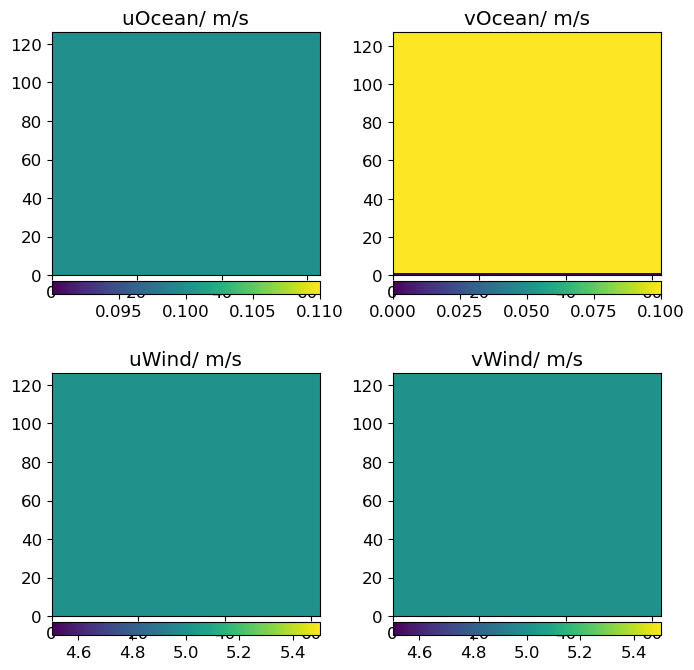

In [111]:
i = -1
forcing_vars = [uOcean[i], vOcean[i], uWind[i], vWind[i]]
forcing_names = ['uOcean', 'vOcean', 'uWind', 'vWind']
forcing_units = ['m/s']*4

plot(forcing_vars, forcing_names, forcing_units, overlap=False)

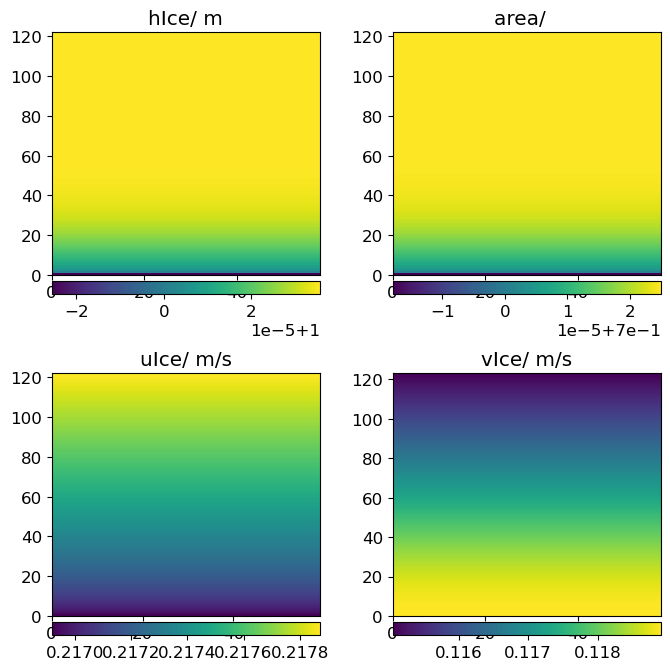

In [112]:
i = -1
ice_vars = [ice[i], area[i], uIce[i], vIce[i]]
ice_names = ['hIce', 'area', 'uIce', 'vIce']
ice_units = ['m', ' ', 'm/s', 'm/s']

plot(ice_vars, ice_names, ice_units, overlap=True)